<a href="https://colab.research.google.com/github/sonyakuma-droid/EMSC2010-W2-P1/blob/main/EMSC2010_Group_Project_1_BBB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project 1: Bush, Bugs and Biodiversity

## 1. Project Overview
Group name: Bugs, Bushes, and Biodiversity

Project week: 5 (Group Project 1)

Project title: *undecided*

Datasets used (name and source): *undecided*

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Seth | MJ | Yes/Partial/No| Add note|
| Data steward | MJ | Mia | Yes| Data excel uploaded to group forum - Can @Seth please add a copy to his GitHub?|
| Analysis / modelling | Mia | Sonya | Yes| Add note|
| Visualisation / interpretation | Sonya | Sienna | Yes/Partial/No| Add note|
| Narrative | Sienna | Seth | Yes/Partial/No| Add note|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

# DATA OVERVIEW - By MJ

We used the “100 Years of Bushfire Data – NSW” dataset, which compiles official fire history records from New South Wales National Parks and Wildlife Service. Each observation represents a single fire event with an associated total burned area in hectares.

To keep things manageable and relevant, I’ve:

- Filtered the data to 2010–2020 (2020 was the latest record)
- Wildfires were grouped by their start year to avoid splitting single events across multiple years.
- Removed prescribed burn records, so we’re only looking at wildfires
- Total 9496 data points

This gives us a cleaner, more focused dataset to work with.

**Possible research question using this dataset:** *“What is the average area burnt per wildfire in NSW between 2010 and 2020? (Looking at Mean & Median?)”*

**Note:** This analysis will treat individual fire events as independent observations and will not account for spatial or climatic correlations between fires within the same season.

**Source:** https://100-years-of-bushfire-unsw-au.opendata.arcgis.com/datasets/45de184df8544897a04d74dfe935321a_0/explore?location=-32.829867%2C147.349790%2C6

***Excel copy of cleaned data available in GitHub repository***

**Reflection - MJ Spencer-Stewart**

As the Data Steward this week I found it challenging locating a suitable dataset for our group on account of slight confusion how we were to use it, and then due to the large size of many databases, or the variability in data record quality. It also was strange deleting many columns from the final database to isolate the Areas columns we needed as it went againt my personal approach to using data - which is to protect and conserve all data at all costs. This is something I'm learning can be approached differently when using Python. I hope this dataset proves usable and produces interesting results.

# ANALYSIS AND MODELLING - by Mia

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #imports - sns was used to create informative statistical graphs

#upload data file here

spreadsheet_name = 'NSW Wildfire Area 2010-2020-1.xlsx'
worksheet_name = 'NSW_fire_areas_2010_2020'
df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name) #getting pandas to read data file
df.head() #checking its uploaded data

,AreaHa
0,185.013589
1,15.652662
2,48.896396
3,233.499839
4,0.364559


In [ ]:
W = np.array(df['AreaHa'])
#W represents average area burnt per wildfire

print(W[:20]) # Display the first 20 values of the array

#Note: when asked to just print(W), values towards end of data sheet were so large that values were represented as 1.85 instead of 185.0.
#Printing a defined number of values, in this case 20, fixed this, now representing true values.

[185.01358851  15.65266201  48.89639633 233.49983883   0.3645593
   1.4588067    1.9436086    2.81801841   0.62408366  13.05262783
  32.44586391   9.05021914  21.02232917   5.76086846   0.45868118
  97.87407475 115.05955589  42.12205427 171.19604563  72.64500988]


In [ ]:
np.mean(W) #mean average area burnt in wildfires
print(np.mean(W))

np.median(W) #median area burnt in wildfires
print(np.median(W))

1362.7279639030887
9.104593705


The **mean** average area burnt per wildfire in NSW between 2010-2020 (W) is **1362.727ha**.

Average area burnt per wildfire in NSW between 2010-2020 is 1362.72ha (important to note that this is an *average of the averages* prodived in the data, could be skewed).

The **median** area burnt per wildfire in NSW between 2010-2020 (W) is **9.104ha**.

**Bootstrap example 1**

In [ ]:
#A is the first bootstrapping example, sample size = 1,000

A = np.random.choice(W, size=(len(W),1000), replace=True)
#pick random numbers from W values, size 1,000 (number of samples), with replacement

print(np.shape(A)) #checking values

(9496, 1000)


**Note**: Executing this command will generate *different randomly chosen numbers* each time it is run.

That means that **everyone will produce different results for the bootstrapped means, medians, and confidence intervals**.

E.g. Mia's mean result for bootstrapping example 1 is 1233.219ha

In [ ]:
bar1 = np.mean(A) #bar1 is the mean of all bootstrap samples together (1,000 samples), producing 1 output

bar2 = np.mean(A, axis=0) #bar2 is the individual means of each bootstrap sample, should produce 1,000 outputs

print(bar1) #Overall mean
print(bar2) #1,000 outputs, individual means of each bootstrap sample

1361.227008840984
[1517.21441132 1487.19610993 1613.7251038  1132.7433159  1346.53366646
 1473.72028075 1497.89405967 1264.26598287 1312.17974451 1250.50336849
 1289.91692386 1500.24848753 1489.87056217 1279.19376486 1274.93477126
 1326.11435603 1150.01225704 1326.88344005 1345.76131555 1390.06011665
 1592.33244507 1327.27338873 1146.2976139  1210.41536647 1354.61140995
 1296.19285042 1210.03337485 1311.30705847 1330.97038584 1298.62299416
 1422.70523203 1155.79348411 1577.0454926  1306.92633558 1320.2463277
 1222.95270304 1266.35825217 1594.45126463 1332.81522177 1583.81876796
 1549.30298295 1453.74354973 1415.9656025  1448.27692088 1243.08264965
 1422.50065172 1388.89814619 1371.75567617 1489.80672747 1601.9092369
 1261.91866689 1594.2364279  1457.09626684 1613.9931061  1567.29635557
 1516.58992987 1358.82943564 1577.49930302 1199.07312635 1295.19454493
 1207.37788189 1288.89375971 1389.4509921  1422.43547897 1356.29010734
 1194.5237063  1355.69293246 1293.07832997 1421.48529587 1214

In [ ]:
CI = np.percentile(bar2, [2.5, 97.5]) #95% confidence interval for bar2
print(CI)

[1092.74859785 1679.64563154]


In [ ]:
print(np.mean(A)) #mean of bootstrap example A
print(np.median(A)) #median of all bootstrap samples in A

print(np.mean(W)) #comparison against true data mean
print (np.median(W)) #comparison against true data median

1361.227008840984
9.10091519
1362.7279639030887
9.104593705


Results in the above cell are pretty close! Demonstrative of Monte Carlo techniques.

**Bootstrap example 2**

In [ ]:
#B is the second bootstrapping example, sample size = 10,000

B = np.random.choice(W, size=(len(W),10000), replace=True)
#pick random numbers from W values, size 10,000 (number of samples) with replacement

print(np.shape(B)) #checking it has the right amount of data points (9496), generating 10,000 samples

(9496, 10000)


In [ ]:
bar3 = np.mean(B) #bar3 is the mean of all bootstrap samples together (10,000), producing 1 output

bar4 = np.mean(B, axis=0) #bar4 is the individual means of each bootstrap sample, should produce 10,000 outputs

print(bar3) #Overall mean
print(bar4[:25]) #The first 25 individual means from bar4

1362.2142089913978
[1314.54416389 1257.84839132 1277.96098175 1422.19078115 1206.11027584
 1560.23404335 1280.77839453 1738.28733637 1121.78652155 1484.56472028
 1536.63955307 1777.51949047 1498.54319436 1114.79328992 1421.66911114
 1119.61114382 1646.01229673 1364.06742865 1589.02930856 1414.27357683
 1200.57984489 1042.33364478 1548.40352135 1687.02264732 1364.4141857 ]


In [ ]:
CI = np.percentile(bar4, [2.5, 97.5]) #95% confidence interval for bar4
print(CI)

[1084.80617395 1708.35277381]


In [ ]:
print(np.mean(B)) #mean of bootstrap example B
print(np.median(B)) #median of all bootstrap samples in B

print(np.mean(W)) #comparison against true data mean
print (np.median(W)) #comparison against true data median

1362.2142089913978
9.10091519
1362.7279639030887
9.104593705


**Reflection - Mia Jaggers**

I felt happily challenged by the analysis and modelling role in the group project this week. The dataset provided to me by MJ was clean and easy to use. I used colab notebooks from previous practicals to upload and read the dataset, and implement bootstrapping techniques. I conducted two bootstrapping examples with sample sizes of 1,000 and 10,000.
I had some trouble managing the amount of datapoints (e.g. having to limit the amount of values printed), making sure data was accurate, and used AI to help fix errors. Excited to have completed some of my first coding, and look forward to building these skills more through the group projects.

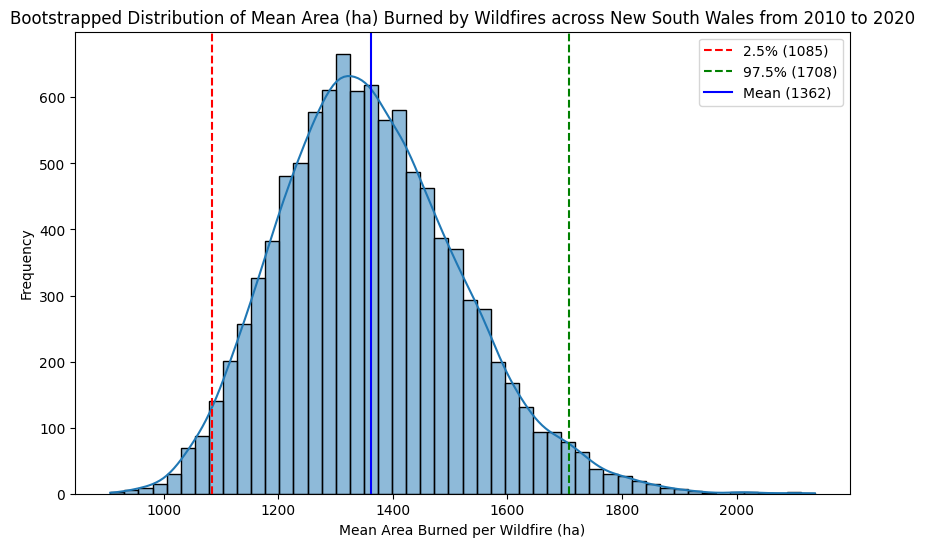

In [ ]:
# Plot: A bootstrap analysis (e.g. 10,000 iterations, bar4) visualised as a histogram of bootstrapped means of hectares (ha) burned
plt.figure(figsize=(10, 6)) #set dimensions of figure
sns.histplot(bar4, bins=50, kde=True) # creating histogram using Seaborn as sns
ci_lower = np.percentile(bar4, 2.5) # 2.5% percentile defines lower bound of 95% confidence interval (CI)
ci_upper = np.percentile(bar4, 97.5) # 97.5% percentile defines upper bound of 95% confidence interval
plt.axvline(ci_lower, color='red', linestyle='--', label=f'2.5% ({ci_lower:.0f})') # show lower CI as dotted red line
plt.axvline(ci_upper, color='green', linestyle='--', label=f'97.5% ({ci_upper:.0f})') # show upper CI as dotted green line
plt.axvline(bar3, color='blue', linestyle='-', label=f'Mean ({bar3:.0f})') # show mean in blue
plt.title('Bootstrapped Distribution of Mean Area (ha) Burned by Wildfires across New South Wales from 2010 to 2020') # plot title
plt.xlabel('Mean Area Burned per Wildfire (ha)') # label x-axis
plt.ylabel('Frequency') #label y-axis
plt.legend() # add legend to plot
plt.show() # display figures

**Visualisation and Interpretation:** Histogram of Bootstrapped Means (above): The distribution of the mean hectares (ha) burned is right-skewed, with a long tail extending past 2,000 ha representing infrequent but high-impact wildfires. While a mean area (ha) of 1362 (95% CI [1085, 1708]) was burned between 2010 -2020 in NSW, the wide confidence interval indicates high uncertainty caused by less frequent extreme fire events.
Note: Code above adapted from https://medium.com/@kritsadakruapat/confidence-intervals-the-art-of-statistics-by-david-spiegelhalter-practical-python-example-1651c1dbe8e0.
Boxplot (below): Shows a significant number of outliers beyond 1800 ha.
Note: Basic code sourced online.

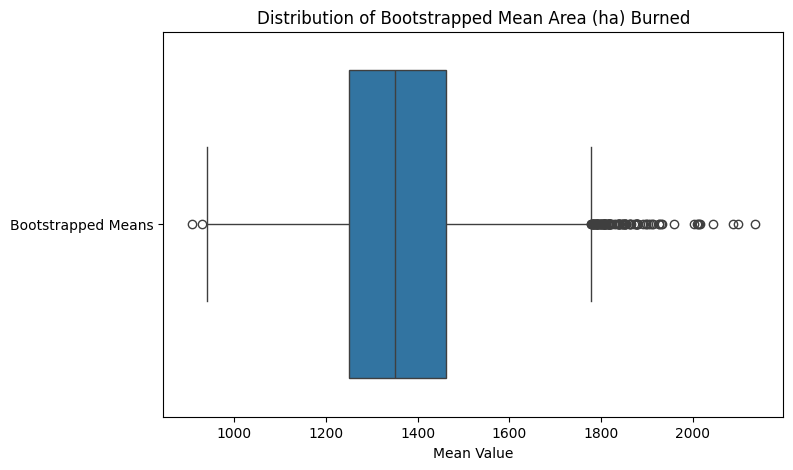

In [30]:
# Convert ouput into pandas DataFrame more suited to plotting with Seaborn
df_boots = pd.DataFrame(bar4, columns=['Bootstrapped Means'])

# Create the box plot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_boots, orient='h') # orient='h' for horizontal orientation
plt.title('Distribution of Bootstrapped Mean Area (ha) Burned')
plt.xlabel('Mean Value')
plt.show()

**Reflection - Sonya Kumar**
Visualisation and interpretation (primary role): In general, I found the visualisation task less challenging than the task of interpretation thanks in large part to the abundance of python coding resources available online. Despite using one to summarise and visualise the data distribution, I remain wary of boxplots and how to interpret them.